## Physics 3. Laboratory experiment #3. Microwaves.

Dr. Ernst Uzhansky, 2024, v0.1.1

Outline of the lab:

#### Day 1

1. Lattice as a polarizer
2. Waveguide (galbo) features

#### Day 2

3. Michelson interferometer
4. Fabry-Peroh interferometer
5. Lloyd interferometer

## Import libraries

In [8]:
import numpy as np  # math functions
import scipy  # scientific functions
import matplotlib.pyplot as plt  # for plotting figures and setting their properties
import pandas as pd  # handling data structures (loaded from files)
from scipy.stats import linregress  # contains linregress (for linear regression)
from scipy.optimize import curve_fit as cfit  # non-linear curve fitting
from sklearn.metrics import r2_score  # import function that calculates R^2 score
# from prettytable import PrettyTable 		# display data in visually table format
import scipy.ndimage as ndimage  # import Multidimensional Image processing package
from scipy.signal import find_peaks  # for find local peaks in a signal

### Part 1. Lattice as a polarizer

Place the detector in front of the transmitter, measure and plot the radiation intensity received by the detector for the following two cases:
1. Without a lattice between the transmitter and the detector
2. With a grating between the transmitter and the detector

Keep in mind that lettice acts as a filter and, technally, it can be considered as a source of polarized microwaves. That is why you have $cos^{4}$ dependence, namely $cos^{2}$ dependence from the source to the lettice, and one more $cos^{2}$ dendence from the lettice to the receiver.

Mind that every graduation mark on the back of the source and receiver correspond to 5 degrees.

**Figure 1.** Intensity vs $cos^2(\theta)$. Case without a polarizer.


[  0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100. 110. 120. 130.
 140. 150. 160. 170. 180.]
Linear fit: slope=0.367194, intercept=0.099024, R^2=0.898288


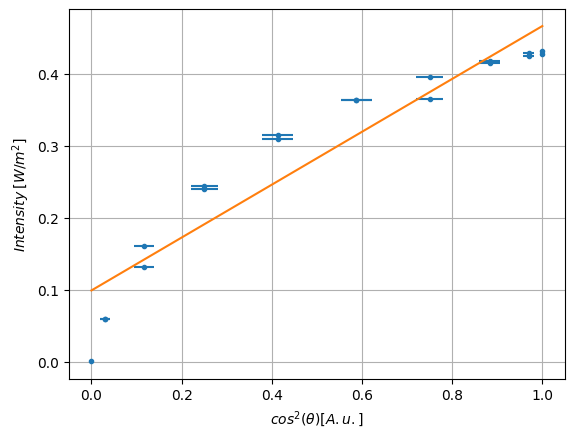

In [4]:
angleoffset = 0
angles2 = np.linspace(0, 180, 19) + angleoffset  # +-4, deg
print(angles2)
intensity2 = np.array((431, 429, 418, 396, 364, 309, 244, 132, 59, 0.6, 59.3, 161, 240.5, 315, 363, 365, 415, 424,
                       428)) / 1000  # ±1e-3, Volt

rad_angles2 = np.deg2rad(angles2)
data2 = np.cos(rad_angles2) ** 2
plt.style.use('default')
delta_theta_deg = 2  # measurement uncertainty in degrees (adjust if different)
delta_theta_rad = np.deg2rad(delta_theta_deg)
# propagate angle uncertainty to x (cos^2) using derivative d(cos^2)/dθ = -2 cos(θ) sin(θ)
xerr = np.abs(-2 * np.cos(rad_angles2) * np.sin(rad_angles2)) * delta_theta_rad
yerr = np.full_like(intensity2, 1e-3)
plt.figure()
plt.grid()
plt.errorbar(x=data2, y=intensity2, xerr=xerr, yerr=yerr, fmt='.')
# Linear regression for intensity2 vs data2 and print R^2
slope, intercept, r_value, p_value, stderr = linregress(data2, intensity2)
pred = slope * data2 + intercept
r2 = r_value ** 2
print(f"Linear fit: slope={slope:.6f}, intercept={intercept:.6f}, R^2={r2:.6f}")
# plot fit line
x_fit = np.linspace(data2.min(), data2.max(), 100)
plt.plot(x_fit, slope * x_fit + intercept, '-', label=f'fit $R^2$={r2:.3f}')
plt.xlabel("$cos^2(\\theta) [A.u.]$")
plt.ylabel("$Intensity_ [W/m^2]$");

**Figure 2.** Intensity vs $sin^4(\theta)$. Case with a polarizer between the source and the receiver.


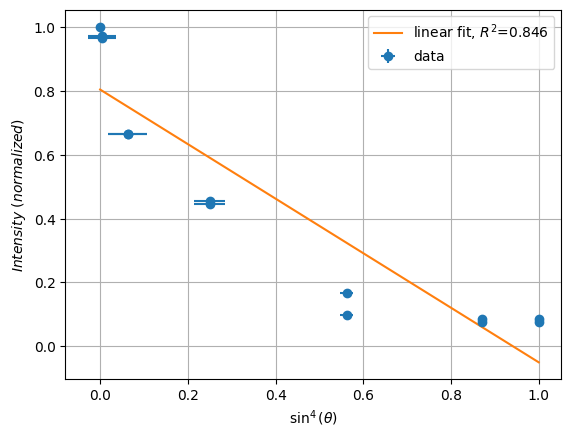

In [5]:
angles = np.linspace(0, 180, 13)  # +-2, deg
angle_err = 2  # degrees
intensity = np.array(
    (35, 35, 69, 185, 275, 400, 414, 403, 275, 189, 41, 31, 31)) / 1000  # ±1e-3, Volt
intensity_err = 1e-3
intensity_err_raw = 1e-3  # measurement uncertainty in Volts
max_intensity = intensity.max()
intensity_norm = intensity / max_intensity
intensity_err = intensity_err_raw / max_intensity
intensity /= max_intensity
# intensity = np.power(voltage, 2) # Volts
data = np.power(np.cos(angles * np.pi / 180), 4)

rad = np.deg2rad(angles)
plt.style.use('default')

data = np.cos(rad) ** 4

# propagate angle uncertainty to x (data) using derivative d(cos^4)/dθ = -4 cos^3(θ) sin(θ) * dθ (radians)
xerr = np.abs(4 * np.sin(rad) ** 3 * np.cos(rad)) * np.deg2rad(angle_err)

# linear regression and R^2
slope, intercept, r_value, p_value, stderr = linregress(data, intensity_norm)
r2 = r_value ** 2
x_fit = np.linspace(data.min(), data.max(), 200)
y_fit = slope * x_fit + intercept

plt.figure()
plt.grid()
plt.errorbar(data, intensity_norm, xerr=xerr, yerr=intensity_err, fmt='o', label='data')
plt.plot(x_fit, y_fit, '-', label=f'linear fit, $R^2$={r2:.3f}')
plt.xlabel("$\\sin^4(\\theta)$")
plt.ylabel("$Intensity\\ (normalized)$")
plt.legend()

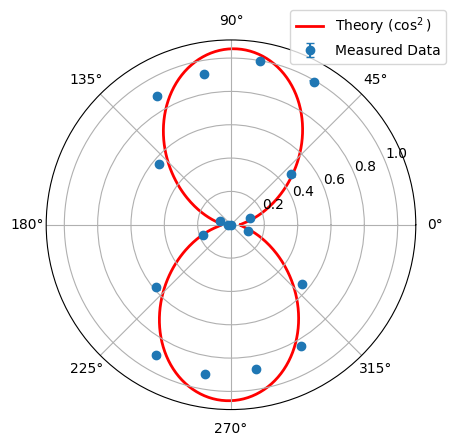

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Data Setup
d = 2.76
q_deg = np.array([0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300, 320, 340])
q_rad = np.radians(q_deg)

# Your data
intensity_linear = np.array([.24, 25, 99, 207, 209, 192, 186, 118, 15, 3.3, 37, 122, 189, 190, 184, 176, 116, 23])

# 2. Normalization and Error
I_max = intensity_linear.max()
I_norm = intensity_linear / I_max

# Error: Assuming 0.1 error in the original units (based on your comment ±1e-1)
# Propagated error for normalized plot:
error_val = 0.1
I_error_norm = np.full_like(I_norm, error_val / I_max)


# 3. Theoretical Model: Malus's Law (The "Shape of 8")
def malus_model(theta, phase, offset):
    # I = I_0 * cos^2(theta - phase) + offset
    # Since we normalized, I_0 is effectively 1, but the fit handles slight variations
    return np.cos(theta - phase) ** 2 + offset


# Fit the model to find the best phase angle
# Initial guess: max at ~80 degrees (approx 1.4 rad) based on data
popt, _ = curve_fit(malus_model, q_rad, I_norm, p0=[1.4, 0])

# Generate smooth curve for plotting
theta_smooth = np.linspace(0, 2 * np.pi, 500)
I_smooth = malus_model(theta_smooth, *popt)

# 4. Plotting
fig = plt.figure()
ax = fig.add_subplot(111, projection='polar')

# Plot Data with Error Bars
# Note: 'zorder' ensures data sits on top of the line
ax.errorbar(q_rad, I_norm, yerr=I_error_norm, fmt='o', capsize=3, label='Measured Data', zorder=2)

# Plot Theoretical Curve
ax.plot(theta_smooth, I_smooth, 'r-', linewidth=2, label=fr'Theory ($\cos^2$)', zorder=1)

# Formatting
ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

plt.show()

### Part 2. Waveguide (galbo) features

Assemble the waveguide device and make measurements according to the instruction list.

**Figure 3.** Perpendicular case. Intensity vs width of the waveguide.

Adjacent fit: slope=10.937951, intercept=-0.048427, R^2=0.325999


Text(0, 0.5, 'Intensity [W/m^2]')

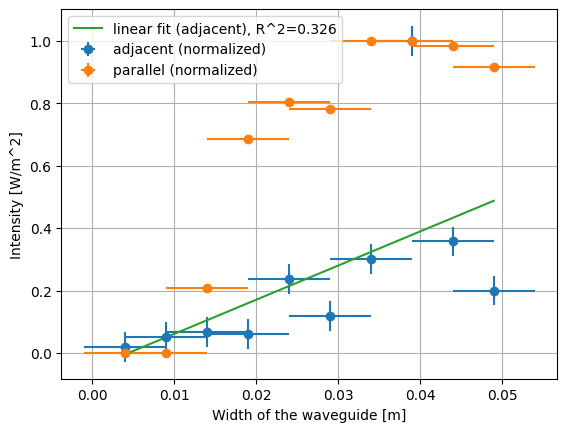

In [6]:
#Perpendicular case
d = (np.array([5, 4.5, 4, 3.5, 3, 2.5, 2, 1.5, 1, 0.5]) - .1) * 1e-2  # ±0.5e-3, metres
d_err = 5e-3
intensity_adjacent_raw = np.array(
    [4.2, 7.5, 21, 6.3, 2.5, 5, 1.3, 1.4, 1.1, 0.4]) * 1e-3  # ±1e-3, Volts // perpendicular

intensity_parallel_raw = np.array([468, 503, 511, 511, 400, 410, 350, 106, 0.14, 0.1])  # ±1e-3, Volts
int_err_raw = 1e-3  # 1 mV

# normalize each series by its max (as in original)
intensity_adjacent = intensity_adjacent_raw / intensity_adjacent_raw.max()
intensity_parallel = intensity_parallel_raw / intensity_parallel_raw.max()
plt.style.use('default')

# propagated measurement uncertainty after normalization
intensity_err_adj = int_err_raw / intensity_adjacent_raw.max()
intensity_err_par = int_err_raw / intensity_parallel_raw.max()

plt.grid()
plt.errorbar(d, intensity_adjacent, xerr=d_err, yerr=intensity_err_adj, fmt='o', label='adjacent (normalized)')
plt.errorbar(d, intensity_parallel, xerr=d_err, yerr=intensity_err_par, fmt='o', label='parallel (normalized)')

# Linear regression for parallel case (normalized)
slope, intercept, r_value, p_value, stderr = linregress(d, intensity_adjacent)
r2 = r_value ** 2
x_fit = np.linspace(d.min(), d.max(), 100)
plt.plot(x_fit, slope * x_fit + intercept, '-', label=f'linear fit (adjacent), R^2={r2:.3f}')

plt.xlabel('Width of the waveguide [m]')
plt.ylabel('Intensity [W/m^2]')
plt.legend()
print(f"Adjacent fit: slope={slope:.6f}, intercept={intercept:.6f}, R^2={r2:.6f}")
plt.xlabel('Width of the waveguide [m]')
plt.ylabel('Intensity [W/m^2]')

## Polar graphs

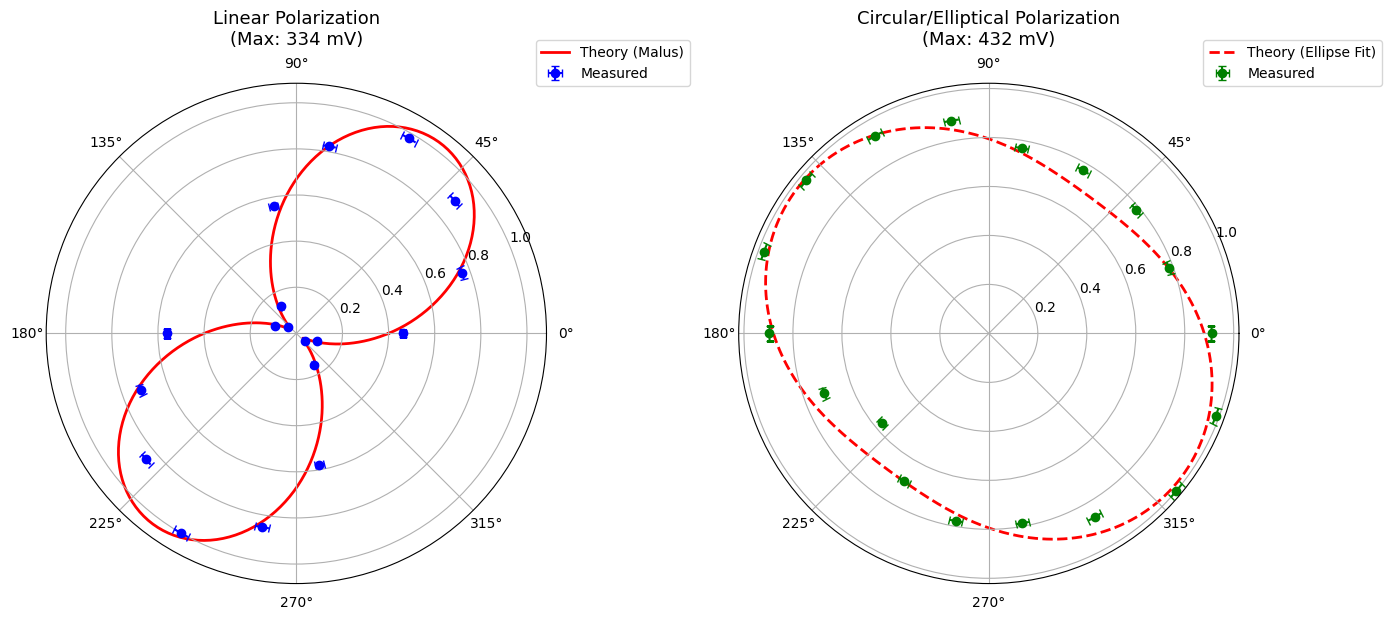

Circular Data Stats -> Average: 361.611, Std: 49.341
R^2 (Linear Fit): 0.9633
R^2 (Circular Fit): 0.7951
Axial Ratio (I_max/I_min): 1.416 (1.0 = Circle, >1.0 = Ellipse)


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# --- 1. Data Entry ---
q_deg = np.array([0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300, 320, 340])
q_rad = np.radians(q_deg)

linear_intensities = np.array([155, 255, 299, 326, 275, 187, 45, 15, 33, 188, 240, 284, 334, 285, 193, 52, 16, 32])
circular_intensities = np.array([393, 338, 339, 332, 332, 381, 402, 420, 422, 387, 309, 246, 300, 336, 340, 374, 432, 426])

# Errors
theta_err_deg = 2.0
theta_err_rad = np.radians(theta_err_deg)
intensity_err_mv = 5.0

# --- 2. Helper Functions ---
def normalize_and_err(data, abs_err):
    max_val = np.max(data)
    norm = data / max_val
    # Scale error: err_norm = err_abs / max_val
    err_norm = np.full_like(data, abs_err / max_val)
    return norm, err_norm, max_val

def malus_law(theta, phase, offset):
    return np.cos(theta - phase)**2 + offset

def ellipse_model(theta, I_maj, I_min, angle_offset):
    return I_maj * np.cos(theta - angle_offset)**2 + I_min * np.sin(theta - angle_offset)**2

# --- 3. Process Data (The Missing Step) ---
# This actually creates the variables needed for fitting
norm_lin, err_lin, max_lin = normalize_and_err(linear_intensities, intensity_err_mv)
norm_circ, err_circ, max_circ = normalize_and_err(circular_intensities, intensity_err_mv)

# --- 4. Fitting ---
# Fit Linear
popt_lin, _ = curve_fit(malus_law, q_rad, norm_lin, p0=[1.0, 0])

# Fit Circular (Guessing initial parameters helps convergence)
popt_circ, _ = curve_fit(ellipse_model, q_rad, norm_circ, p0=[1.0, 0.5, 0])

# Generate smooth curves
theta_smooth = np.linspace(0, 2 * np.pi, 500)
curve_lin = malus_law(theta_smooth, *popt_lin)
curve_circ = ellipse_model(theta_smooth, *popt_circ)

# --- 5. Plotting ---
fig = plt.figure(figsize=(14, 7))

# Graph 1: Linear
ax1 = fig.add_subplot(121, projection='polar')
ax1.errorbar(q_rad, norm_lin, xerr=theta_err_rad, yerr=err_lin, fmt='o', capsize=3, label='Measured', color='blue', zorder=2)
ax1.plot(theta_smooth, curve_lin, 'r-', linewidth=2, label='Theory (Malus)', zorder=1)
ax1.set_title(f"Linear Polarization\n(Max: {max_lin} mV)", va='bottom', fontsize=13)
ax1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# Graph 2: Circular
ax2 = fig.add_subplot(122, projection='polar')
ax2.errorbar(q_rad, norm_circ, xerr=theta_err_rad, yerr=err_circ, fmt='o', capsize=3, label='Measured', color='green', zorder=2)
ax2.plot(theta_smooth, curve_circ, 'r--', linewidth=2, label='Theory (Ellipse Fit)', zorder=1)
ax2.set_title(f"Circular/Elliptical Polarization\n(Max: {max_circ} mV)", va='bottom', fontsize=13)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

# --- 6. Statistics ---
print(f"Circular Data Stats -> Average: {np.mean(circular_intensities):.3f}, Std: {np.std(circular_intensities):.3f}")

# Calculate R^2
y_pred_lin = malus_law(q_rad, *popt_lin)
y_pred_circ = ellipse_model(q_rad, *popt_circ)

r2_lin = r2_score(norm_lin, y_pred_lin)
r2_circ = r2_score(norm_circ, y_pred_circ)

print(f"R^2 (Linear Fit): {r2_lin:.4f}")
print(f"R^2 (Circular Fit): {r2_circ:.4f}")

# Axial Ratio Calculation
axial_ratio = popt_circ[0] / popt_circ[1]
print(f"Axial Ratio (I_max/I_min): {axial_ratio:.3f} (1.0 = Circle, >1.0 = Ellipse)")

part with plastic

-0.7745116555385473 1140.649295715244 0.0939008749877511
[0.03266667 0.036      0.0375     0.06133333]
lambda_g = 2.96090130683669 ± 0.08327933053448938 cm


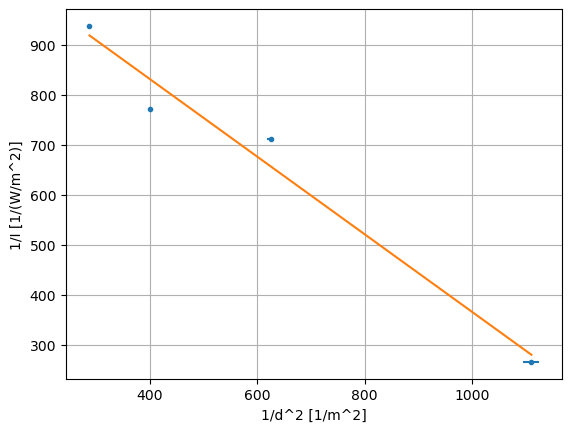

In [5]:
d = np.array([2.95, 2.5, 2, 1.5]) * 1e-2  # ±1e-4, metres
d_err = 1e-4  # Uncertainty in d for 'd'

max1 = np.mean(np.diff(np.array([3.3, 4.9, 6.4, 8.1, 9.9, 11.3, 13.1]) * 1e-2))  # ±2e-2,
max2 = np.mean(np.diff(np.array([1.5, 3, 4.7, 6.9]) * 1e-2))
max3 = np.mean(np.diff(np.array([3.4, 5.3, 7.2, 9.1, 10.9]) * 1e-2))
max4 = np.mean(np.diff(np.array([1.8, 4.9, 8, 11]) * 1e-2))

data_raw_err = 2e-2  # Uncertainty in the raw max values
data = np.array([max1, max2, max3, max4]) * 2
data_err = data_raw_err * 2  # Propagated uncertainty for 'data'

x_values = 1 / ((2 * d) ** 2)
y_values = 1 / (data ** 2)

# Calculate xerror using error propagation for x = 1/(4d^2)
xerr_values = np.abs(-1 / (2 * d ** 3)) * d_err

regress = linregress(x_values, y_values)
slope = regress.slope
intercept = regress.intercept
stderr = regress.stderr
intercept_stderr = regress.intercept_stderr

plt.style.use('default')

print(slope, intercept, stderr)

print(data)
plt.figure()
plt.errorbar(x_values, y_values, xerr=xerr_values, yerr=stderr, fmt='.')
plt.plot(x_values, slope * x_values + intercept)
plt.xlabel('1/d^2 [1/m^2]')
plt.ylabel('1/I [1/(W/m^2)]')
plt.grid()
lam_g = 1 / np.sqrt(intercept)
lam_g_err = 0.5 * intercept ** (-1.5) * intercept_stderr
print("lambda_g =", lam_g * 1e2, "±", lam_g_err * 1e2, "cm")

In [56]:
lam = 2.8 / 100
L = 15.2 / 100
d_circular = (2 * L / np.sqrt(8 * L / lam - 1)) * 100
print(f"{d_circular=}")

d_linear = (L / np.sqrt(4 * L / lam - 1)) * 100
print(f"{d_linear=}")

d_circular=4.667070689581294
d_linear=3.3397088454555126


In [18]:
q = np.array([0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300, 320, 340])  # ±2, angels
q = np.radians(q)
### LINEAR ###
linear_intensities = np.array((155, 255, 299, 326, 275, 187, 45, 15, 33, 188, 240, 284, 334, 285, 193, 52, 16, 32))
circular_intensities = np.array(
    (393, 338, 339, 332, 332, 381, 402, 420, 422, 387, 309, 246, 300, 336, 340, 374, 432, 426))

# Errors
theta_err_deg = 2.0
theta_err_rad = np.radians(theta_err_deg)
intensity_err_mv = 5.0


def normalize_and_err(data, abs_err):
    max_val = np.max(data)
    norm = data / max_val
    # Scale error: err_norm = err_abs / max_val
    err_norm = np.full_like(data, abs_err / max_val)
    return norm, err_norm, max_val


def malus_law(theta, phase, offset):
    return np.cos(theta - phase) ** 2 + offset


def ellipse_model(theta, I_maj, I_min, angle_offset):
    return I_maj * np.cos(theta - angle_offset) ** 2 + I_min * np.sin(theta - angle_offset) ** 2

from scipy.optimize import curve_fit
# Fit Linear
popt_lin, _ = curve_fit(malus_law, q_rad, norm_lin, p0=[1.0, 0])

# Fit Circular
popt_circ, _ = curve_fit(ellipse_model, q_rad, norm_circ, p0=[1.0, 0.5, 0])

theta_smooth = np.linspace(0, 2 * np.pi, 500)
curve_lin = malus_law(theta_smooth, *popt_lin)
curve_circ = ellipse_model(theta_smooth, *popt_circ)

fig = plt.figure(figsize=(14, 7))

# --- Graph 1: Linear ---
ax1 = fig.add_subplot(121, projection='polar')
ax1.errorbar(q_rad, norm_lin, xerr=theta_err_rad, yerr=err_lin, fmt='o', capsize=3, label='Measured', color='blue', zorder=2)
ax1.plot(theta_smooth, curve_lin, 'r-', linewidth=2, label='Theory (Malus)', zorder=1)
ax1.set_title(f"Linear Polarization\n(Max: {max_lin} mV)", va='bottom', fontsize=13)
ax1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# --- Graph 2: Circular ---
ax2 = fig.add_subplot(122, projection='polar')
ax2.errorbar(q_rad, norm_circ, xerr=theta_err_rad, yerr=err_circ, fmt='o', capsize=3, label='Measured', color='green', zorder=2)
ax2.plot(theta_smooth, curve_circ, 'r--', linewidth=2, label='Theory (Ellipse Fit)', zorder=1)
ax2.set_title(f"Circular/Elliptical Polarization\n(Max: {max_circ} mV)", va='bottom', fontsize=13)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

print(f"Average: {np.mean(circular_intensities):3f}, std: {np.std(circular_intensities):3f}")

y_pred_lin = malus_law(q_rad, *popt_lin)
y_pred_circ = ellipse_model(q_rad, *popt_circ)

# 2. Calculate R^2 using sklearn
r2_lin = r2_score(norm_lin, y_pred_lin)
r2_circ = r2_score(norm_circ, y_pred_circ)

print(f"R^2 (Linear): {r2_lin:.4f}")
print(f"R^2 (Circular): {r2_circ:.4f}")

NameError: name 'q_rad' is not defined

### Day 2. Building interferometers.

--- Fit Results ---
Amplitude: 287.95 mV
Calculated Wavelength (Lambda): 2.6143 cm
Wavelength Error: ±0.0084 cm


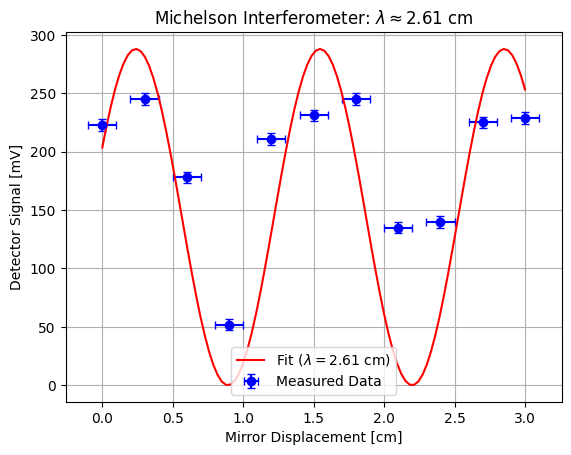

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize

plt.style.use('default')

# --- Data Input ---
# Assuming raw distance data is in cm (based on 20.3, 20.6 steps)
x0 = 20  # initial distance offset [cm]
dists_raw = np.array([20, 20.3, 20.6, 20.9, 21.2, 21.5, 21.8, 22.1, 22.4, 22.7, 23])
dists_max = dists_raw - x0  # Distance relative to start [cm]

# Voltage in mV
V_max = np.array([223, 245, 178, 52, 211, 231, 245, 135, 140, 225, 229])

# --- Error Definitions ---
# x_err: 1mm = 0.1 cm
x_err = 0.1
# y_err: 5mV
y_err = 5.0


# --- Model ---
# I = A * sin^2(2*pi*k*x + phase)
# For Michelson, period is Lambda/2.
# sin^2(B*x) has period pi/B.
# Here B = 2*pi*k. Period = pi / (2*pi*k) = 1 / (2k).
# So 1/(2k) = Lambda/2 => Lambda = 1/k.
def wave(x, A, k, phase):
    return A * (np.sin(x * k * 2 * np.pi + phase)) ** 2


# --- Fitting ---
# Initial guess (p0):
# A = 250 (approx max voltage)
# k = 1/2.8 (approx 1/Lambda)
# phase = 0.2 (guess)
p0 = [250, 1 / 2.8, 0.2]

parameters, covariance = scipy.optimize.curve_fit(wave, dists_max, V_max, p0=p0, sigma=np.full_like(V_max, y_err),
                                                  absolute_sigma=True)

# Extract fit errors (sqrt of diagonal elements of covariance matrix)
perr = np.sqrt(np.diag(covariance))

fit_A = parameters[0]
fit_k = parameters[1]
fit_lambda = 1 / fit_k
fit_lambda_err = perr[1] / (fit_k ** 2)  # Error propagation for 1/k

print(f"--- Fit Results ---")
print(f"Amplitude: {fit_A:.2f} mV")
print(f"Calculated Wavelength (Lambda): {fit_lambda:.4f} cm")
print(f"Wavelength Error: ±{fit_lambda_err:.4f} cm")

# --- Plotting ---

# Plot Data with Error Bars
plt.errorbar(dists_max, V_max, xerr=x_err, yerr=y_err, fmt="bo", label="Measured Data", capsize=3)

# Plot Fit Curve
lin = np.linspace(0, dists_max.max(), 100)
plt.plot(lin, wave(lin, *parameters), 'r-', label=f"Fit ($\\lambda={fit_lambda:.2f}$ cm)")

plt.xlabel("Mirror Displacement [cm]")
plt.ylabel("Detector Signal [mV]")
plt.title(f"Michelson Interferometer: $\\lambda \\approx {fit_lambda:.2f}$ cm")
plt.legend()
plt.grid(True)
plt.show()

**Figure .** Michelson interferometer. Voltage vs. distance.

Wavelength measured with Fabry-Perot interferometer is 2.9 ± 0.2 cm


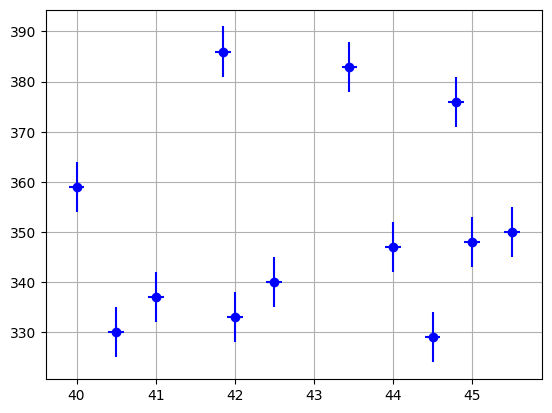

In [23]:
# Fabry-Perot interferometer
mirror_1_d1 = 40  # ±1e-3 m
# mirror_1_d2 = 1  # ±1e-3 m
mirror_2 = 51.1  # ±1e-3 m

d = np.array((40, 40.5, 41, 41.85, 42, 42.5, 44, 44.5,45, 45.5,44.8,43.45))
intensities = np.array((359, 330,337,386,333, 340, 347, 329,348, 350,376, 383))

plt.errorbar(d, intensities, xerr=0.1, yerr=5, fmt="bo", label="meas")
plt.grid()
"""
d11 = mirror_1_d1 - mirror_2
d21 = mirror_1_d2 - mirror_2
"""
max1 = 41.85
max2 = 43.45
max3 = 44.8
max_err = 0.1

dist1 = max2-max1
dist2 = max3-max2
dist_err = np.sqrt(2)*max_err

lamb_1 = (dist1 + dist2)# 10 wavelengths, and the mirror moved half as much as the added path
lamb_1_err = dist_err*np.sqrt(2)

print(f'Wavelength measured with Fabry-Perot interferometer is {lamb_1:.1f} ± {lamb_1_err:.1f} cm')


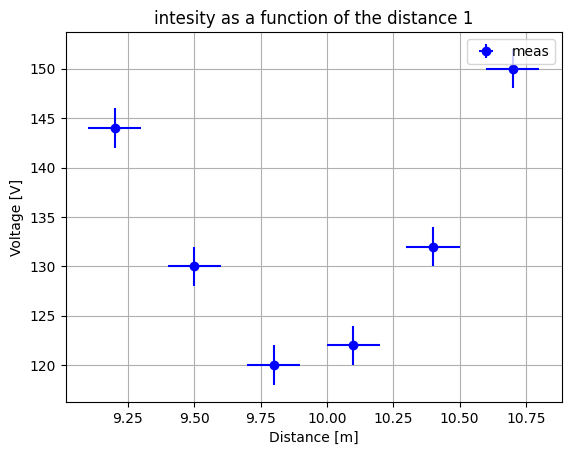

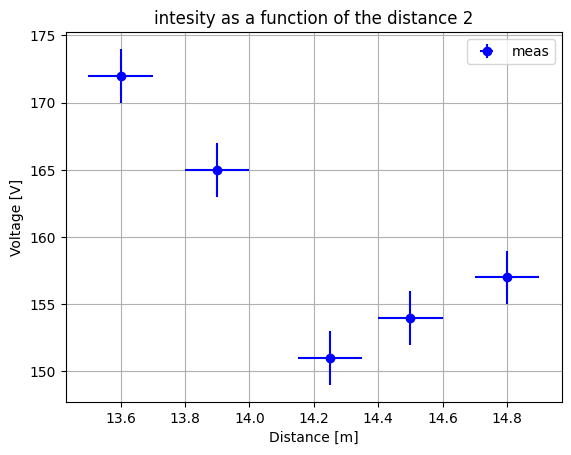

Wavelength measured with Loyd mirror is 2.113 ± 0.342 cm


In [27]:
from utils import propagate_error

##%% Loyd Second meas
AC = 0.86  #meter
h_3 = 0.1415
h0 = 1.5
h1 = (9.8-h0)*1e-2
h2 = (14.25 -h0)*1e-2
values_around_min1_dis = np.array([9.2, 9.5, 9.8, 10.1, 10.4, 10.7])  # +-0.005 meters
values_around_min1_int = np.array([144 , 130 ,120 , 122, 132, 150])  # Volts
values_around_min2_dis = np.array([13.6, 13.9, 14.25, 14.5, 14.8])
values_around_min2_int = np.array([172, 165, 151, 154, 157])
plt.errorbar(values_around_min1_dis, values_around_min1_int, xerr=0.1, yerr=2, fmt="bo", label="meas")
delta = h2 - h1

plt.xlabel("Distance [m]")
plt.ylabel("Voltage [V]")
plt.title(label="intesity as a function of the distance 1")
plt.legend()
plt.grid()
plt.show()
plt.errorbar(values_around_min2_dis, values_around_min2_int, xerr=0.1, yerr=2, fmt="bo", label="meas")
plt.xlabel("Distance [m]")
plt.ylabel("Voltage [V]")
plt.title(label="intesity as a function of the distance 2")
plt.legend()
plt.grid()
plt.show()

def lambda_func(h1,h2,AC):
    return ((4*h2**2+AC**2)**0.5 - (4*h1**2+AC**2)**0.5)
lambda_L3 = ((4*h2**2+AC**2)**0.5 - (4*h1**2+AC**2)**0.5)*1e2
lambda_L3_err = propagate_error(lambda_func, (h1,h2,AC), (5e-3, 5e-3, 1e-3))*1e2

"""
AB_3 = (((AC / 2) ** 2) + (h_3 ** 2)) ** 0.5
lambda_L3 = ((AC - 2 * AB_3) * 0.5) * -(10 ** 2)
"""
print(f'Wavelength measured with Loyd mirror is {lambda_L3:.3f} ± {lambda_L3_err:.3f} cm')